## Spatial plotting of $kelch13$ A724E, and preparing provincal and district tables

In [1]:
import os
import pandas as pd
import geopandas as gpd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [2]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [3]:
DIR_SEQDATA = "../seqdata/all/summaries/HRP23_MIS2024"
DIR_GEODATA = "../geodata/"
DIR_FIGS = "../figures/fig1"
os.makedirs(DIR_FIGS, exist_ok=True)
save_results = False

In [4]:
W = 3.4 # roughly width of one column
KEEP_GEOCOLUMNS = ['province', 'district', 'area_sqkm', 'center_lat', 'center_lon', 'geometry']

## Functions

In [5]:
def summarise_prevalence(d: pd.DataFrame) -> str:
    return f"""
    Samples: {d.n_samples.sum()}
    Passing: {d.n_passed.sum()}
    Kelch13 A724E 
        Mutant: {int(d.n_mut.sum())} ({100*int(d.n_mut.sum())/d.n_passed.sum():.2f}%)
        Mixed: {int(d.n_mixed.sum())} ({100*int(d.n_mixed.sum())/d.n_passed.sum():.2f}%)
        WT: {d.n_wt.sum()} ({100*int(d.n_wt.sum())/d.n_passed.sum():.2f}%)
        Mutant + Mixed: {int(d.n_mut.sum()) + int(d.n_mixed.sum())}
        Prevalence: {100*(int(d.n_mut.sum()) + int(d.n_mixed.sum()))/d.n_passed.sum():.2f}%
    """

In [6]:
def summarise_regions(d: pd.DataFrame, name: str = 'District') -> str:
    return f"""
    {name} data
    ----------------------------------------------------------------------------
    A total of {d.shape[0]} {name.lower()}s exist.
    Sequencing data (>0 passing sample) is available for {d.query('n_passed > 0').shape[0]} {name.lower()}s.
    {name}s with < 5 samples: {d.query('n_passed < 5').shape[0]}
    {name}s with >=5 samples: {d.query('n_passed >= 5').shape[0]}
    {name}s with >=10 samples: {d.query('n_passed >= 10').shape[0]}
    {name}s with >=20 samples: {d.query('n_passed >= 20').shape[0]}
    """

## Load & merge data

#### Districts

In [7]:
df_prev = (
    pd.read_csv(
        f"{DIR_SEQDATA}/summary.variants.prevalence-district.csv"
    )
    .query("mutation == 'kelch13-A724E'")
    .drop(["gene", "chrom", "mut_type", "aa_pos", "aa_change"], axis=1)
)
df_prev['summary'] = [
    f"{r['prevalence']:.1f}% ({int(r['n_mut'] + r['n_mixed'])}/{int(r['n_passed'])})"
    for _, r in df_prev.iterrows()
]

df_geo = gpd.read_file(
    f"{DIR_GEODATA}/zmb_admin_boundaries.shp",
    layer="zmb_admin2"
)
df_geo['district'] = df_geo['adm2_name'].str.lower()
df_geo['province'] = df_geo['adm1_name'].str.lower()
df_geo = df_geo[KEEP_GEOCOLUMNS]

df_district = df_geo.merge(
    right=df_prev,
    how='left', # let's keep event the missing districts
    on='district',
    validate='1:1'
)
# Check we didn't loose any ditricts with samples
assert df_prev.query("n_passed > 0").shape[0] == df_district.query("n_passed > 0").shape[0]

In [8]:
print(
    summarise_regions(df_district) + summarise_prevalence(df_district)
)


    District data
    ----------------------------------------------------------------------------
    A total of 116 districts exist.
    Sequencing data (>0 passing sample) is available for 82 districts.
    Districts with < 5 samples: 22
    Districts with >=5 samples: 60
    Districts with >=10 samples: 51
    Districts with >=20 samples: 32
    
    Samples: 1949.0
    Passing: 1949.0
    Kelch13 A724E 
        Mutant: 111 (5.70%)
        Mixed: 118 (6.05%)
        WT: 1720.0 (88.25%)
        Mutant + Mixed: 229
        Prevalence: 11.75%
    


### Province

In [9]:
df_prev = (
    pd.read_csv(
        f"{DIR_SEQDATA}/summary.variants.prevalence-province.csv"
    )
    .query("mutation == 'kelch13-A724E'")
    .drop(["gene", "chrom", "mut_type", "aa_pos", "aa_change"], axis=1)
)

df_geo = gpd.read_file(
    f"{DIR_GEODATA}/zmb_admin_boundaries.shp",
    layer="zmb_admin1"
)
df_geo['province'] = [s.lower().replace("-", "") for s in df_geo['adm1_name']]
df_geo = df_geo[[c for c in KEEP_GEOCOLUMNS if c != 'district']]

In [10]:
df_province = df_geo.merge(
    right=df_prev,
    how='left', # let's keep event the missing districts
    on='province',
    validate='1:1'
)
# Check we didn't loose any ditricts with samples
assert df_province.query("n_passed > 0").shape[0] == df_province.query("n_passed > 0").shape[0]

#### Prepare city data

In [11]:
cities = pd.DataFrame({
    "city": ["Lusaka", "Kaoma"],
    "lat": [-15.4167, -14.7833],
    "lon": [28.2833, 24.800]
})
gdf_cities = gpd.GeoDataFrame(
    cities,
    geometry=gpd.points_from_xy(cities["lon"], cities["lat"]),
    crs="EPSG:4326"   # important!
).to_crs(df_district.crs)

## Annotate sample size bins

In [12]:
bins = [10, 19, 49, 10_000]
bin_labels = [r"$10-19$", r"$20-49$", r"$\geq 50$"]
bin_point_sizes = dict(zip(bin_labels, [20, 50, 100]))

In [13]:
df_district["n_passed_bins"] = pd.cut(df_district["n_passed"],
                                      bins=bins,
                                      include_lowest=True,
                                      labels=bin_labels
                                     )

In [14]:
df_district["n_passed_bins_sizes"] = [bin_point_sizes.get(b) for b in df_district["n_passed_bins"]]

### Filter

In [15]:
df_plot = df_district.query("n_passed >= 10")

In [16]:
print(summarise_prevalence(df_plot))


    Samples: 1843.0
    Passing: 1843.0
    Kelch13 A724E 
        Mutant: 104 (5.64%)
        Mixed: 110 (5.97%)
        WT: 1629.0 (88.39%)
        Mutant + Mixed: 214
        Prevalence: 11.61%
    


- Almost no change on prevalence

In [17]:
1843/1950

0.9451282051282052

## Plot districts

In [18]:
LW = 0.5
MIN_LON, MAX_LON = 21, 34

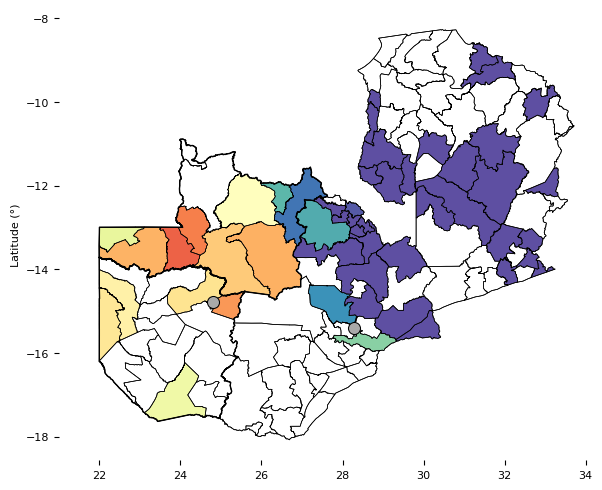

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(W*2, 8))

# Plot prevalence of A724E
df_plot.plot(
    column='prevalence',
    cmap='Spectral_r',
    vmin=0, vmax=100,
    # Unfortunately, adding the cbar distorts the plot size; handle separately
    # legend=True,
    # legend_kwds=dict(label="Prevalence (%)", 
    #                  shrink=0.3,
    #                  aspect=10),
    ax=ax
)

# Plot district outlines
df_district.boundary.plot(
    lw=LW, color='black',
    ax=ax
)

# Strengthen outer border
gpd.GeoSeries([df_district.union_all()]).boundary.plot(ax=ax,
                                                       lw=LW, 
                                                       color='black')

# Plot Lusaka
if True:
    # .query("city == 'Lusaka'")
    gdf_cities.plot(ax=ax, 
                    color="darkgrey",
                    ec='black', 
                    lw=0.75,
                    markersize=75,
                    zorder=10)

# Plot important province
if True:
    important = ['western', 'northwestern']
    df_province.query("province in @important").boundary.plot(lw=1, color='black', ax=ax)
# if True:
#     df_province.boundary.plot(lw=1, color='black', ax=ax)


# Limits
ax.set_xlim(MIN_LON, MAX_LON)

# Labels
ax.set_ylabel("Latitude (°)")

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.zambia_prevalence.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.zambia_prevalence.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

*Code below run once to get colorbar*

In [20]:
# fig, ax = plt.subplots(1, 1, figsize=(W*2, 8))

# # Plot prevalence of A724E
# cbar = df_plot.plot(
#     column='prevalence',
#     cmap='Spectral_r',
#     vmin=0, vmax=100,
#     # Unfortunately, adding the legend distorts the plot size; handle separately
#     legend=True,
#     legend_kwds=dict(label="Prevalence of A724E (%)", 
#                      shrink=0.3,
#                      aspect=10, orientation='horizontal'),
#     ax=ax
# )

# if save_results:
#     fig.savefig(f"{DIR_FIGS}/plot.zambia_prevalence_cbar.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)

In Illustrator: 
Map, delete background, delete x-ticks after confirmed alignment:
- X = 231.271
- Y = 183.1344

Longitude:
- X = 318.9032
- Y = 465.4823

## Plot longitude

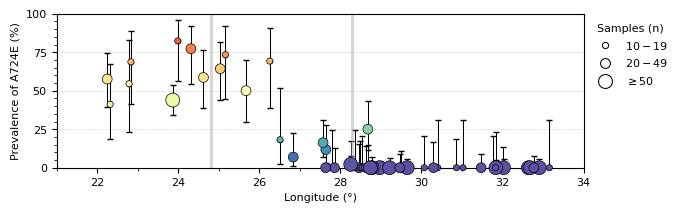

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(W*2, 2))

ax.scatter(
    x="center_lon",
    y="prevalence",
    s="n_passed_bins_sizes",
    c="prevalence",
    cmap="Spectral_r",
    vmin=0, vmax=100,
    ec='black', lw=0.5,
    clip_on=False,
    #color='black',
    zorder=10,
    data=df_plot,
)

ax.errorbar(x=df_plot["center_lon"],
            y=df_plot["prevalence"],
            fmt='.',
            yerr=(df_plot["prevalence"] - df_plot['prevalence_lowci'], 
                  df_plot['prevalence_highci'] - df_plot["prevalence"]),
            color='black',
            lw=0.75,
            capsize=2
           )

# Limits
ax.set_ylim(0, 100)
ax.set_xlim(MIN_LON, MAX_LON)

# Lines
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(plt.MultipleLocator(25))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(axis='y', lw=0.5, ls='dashed', alpha=0.5)

# Labels
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Prevalence of A724E (%)")

# Legend
if True:
    ax.legend(handles=[Line2D([0], [0], lw=0, marker='o', color='none', mec='black', markeredgewidth=0.75, markersize=s**0.5, label=l)
                       for l, s in bin_point_sizes.items()],
              title="Samples (n)", bbox_to_anchor=(1, 1), loc="upper left", frameon=False)


if True:
    for _, row in gdf_cities.iterrows():
        ax.axvline(row['lon'], lw=2, alpha=0.5, color='darkgrey')


if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.zambia_long.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.zambia_long.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

### District statistics

In [40]:
df_plot.sort_values("prevalence", ascending=False)[['district', 'prevalence', 'n_mixed', 'n_mut', 'summary']].head()

,district,prevalence,n_mixed,n_mut,summary
77,kabompo,82.352941,4.0,10.0,82.4% (14/17)
79,manyinga,77.272727,7.0,10.0,77.3% (17/22)
110,nkeyema,73.333333,5.0,6.0,73.3% (11/15)
78,kasempa,69.230769,4.0,5.0,69.2% (9/13)
83,zambezi,68.750000,5.0,6.0,68.8% (11/16)


In [41]:
df_plot.query("prevalence >= 50").sort_values("prevalence", ascending=False)

,province,district,area_sqkm,center_lat,center_lon,geometry,mutation,n_mixed,n_mut,n_samples,...,n_wt,per_wt,per_mixed,per_mut,prevalence,prevalence_lowci,prevalence_highci,summary,n_passed_bins,n_passed_bins_sizes
77,north-western,kabompo,7121.666891,-13.517140,23.987813,"POLYGON ((23.53463 -12.99531, 23.8217 -12.9969...",kelch13-A724E,4.0,10.0,17.0,...,3.0,17.647059,23.529412,58.823529,82.352941,56.568213,96.201493,82.4% (14/17),$10-19$,20.0
79,north-western,manyinga,7422.777595,-13.080897,24.311693,"POLYGON ((24.10251 -12.49023, 24.1046 -12.4912...",kelch13-A724E,7.0,10.0,22.0,...,5.0,22.727273,31.818182,45.454545,77.272727,54.629638,92.179374,77.3% (17/22),$20-49$,50.0
110,western,nkeyema,3774.444582,-14.861437,25.162146,"POLYGON ((25.59694 -14.53638, 25.59693 -14.536...",kelch13-A724E,5.0,6.0,15.0,...,4.0,26.666667,33.333333,40.000000,73.333333,44.899676,92.212845,73.3% (11/15),$10-19$,20.0
78,north-western,kasempa,21877.452879,-13.794901,26.256908,"POLYGON ((26.00844 -12.86956, 26.01067 -12.873...",kelch13-A724E,4.0,5.0,13.0,...,4.0,30.769231,30.769231,38.461538,69.230769,38.573834,90.907961,69.2% (9/13),$10-19$,20.0
83,north-western,zambezi,13974.013799,-13.598935,22.831931,"POLYGON ((23.53493 -12.99709, 23.53489 -12.997...",kelch13-A724E,5.0,6.0,16.0,...,5.0,31.250000,31.250000,37.500000,68.750000,41.337936,88.983005,68.8% (11/16),$10-19$,20.0
80,north-western,mufumbwe,18879.142256,-13.766065,25.035149,"POLYGON ((25.32791 -12.89853, 25.32805 -12.898...",kelch13-A724E,10.0,8.0,28.0,...,10.0,35.714286,35.714286,28.571429,64.285714,44.065031,81.359334,64.3% (18/28),$20-49$,50.0
101,western,kaoma,8992.681965,-14.518460,24.621363,"POLYGON ((24.67384 -13.96041, 24.67529 -13.960...",kelch13-A724E,12.0,5.0,29.0,...,12.0,41.379310,41.379310,17.241379,58.620690,38.936279,76.475979,58.6% (17/29),$20-49$,50.0
114,western,sikongo,8087.301539,-15.322965,22.247363,"POLYGON ((22.03888 -14.44568, 22.03904 -14.445...",kelch13-A724E,13.0,6.0,33.0,...,14.0,42.424242,39.393939,18.181818,57.575758,39.215302,74.523818,57.6% (19/33),$20-49$,50.0
100,western,kalabo,9080.826985,-14.856262,22.785882,"POLYGON ((22.04535 -14.02934, 22.0482 -14.0294...",kelch13-A724E,4.0,2.0,11.0,...,5.0,45.454545,36.363636,18.181818,54.545455,23.379360,83.251191,54.5% (6/11),$10-19$,20.0
84,north-western,kalumbila,16427.716027,-12.362424,25.671232,"POLYGON ((25.46043 -11.71128, 25.46251 -11.711...",kelch13-A724E,13.0,0.0,26.0,...,13.0,50.000000,50.000000,0.000000,50.000000,29.927218,70.072782,50.0% (13/26),$20-49$,50.0


### Prevalence relative to Lusaka

In [42]:
LON_LUSAKA = gdf_cities.query("city == 'Lusaka'").lon[0]
print(LON_LUSAKA)

28.2833


In [43]:
df_wlusaka = df_plot.query("center_lon < @LON_LUSAKA")
df_elusaka = df_plot.query("center_lon >= @LON_LUSAKA")

In [44]:
print(f"""
    We have {df_plot.shape[0]} districts with 10 or more samples.
    Of these, {(df_plot.prevalence > 0).sum()} have A724E.

    We have {df_wlusaka.shape[0]} districts west of Lusaka, and {df_elusaka.shape[0]} east of it.
    West of Lusaka, {(df_wlusaka.prevalence > 0).sum()} districts have A724E.

    The prevalence in districts west of lusaka: {summarise_prevalence(df_wlusaka)}
""")


    We have 51 districts with 10 or more samples.
    Of these, 18 have A724E.

    We have 21 districts west of Lusaka, and 30 east of it.
    West of Lusaka, 17 districts have A724E.

    The prevalence in districts west of lusaka: 
    Samples: 631.0
    Passing: 631.0
    Kelch13 A724E 
        Mutant: 98 (15.53%)
        Mixed: 108 (17.12%)
        WT: 425.0 (67.35%)
        Mutant + Mixed: 206
        Prevalence: 32.65%
    



In [45]:
17/18

0.9444444444444444

### Output tables

In [46]:
mutation_column_names = {
    "prevalence_table": "Prevalence (95% CI) $-$ %",
    "n_passed": "N",
    "n_mut": "Mutant $-$ n",
    "n_mixed": "Mixed $-$ n",
    "n_total": "Mutant or Mixed $-$ n"
}

In [47]:
def annotate_for_manuscript(df: pd.DataFrame) -> pd.DataFrame:
    # Annotations
    df_geography = df.copy()
    df_geography['n_total'] = df_geography['n_mut'] + df_geography['n_mixed']
    df_geography["prevalence_table"] = [
        f"{r['prevalence']:.1f} ({r['prevalence_lowci']:.1f}-{r['prevalence_highci']:.1f})"
        for _, r in df_geography.iterrows()
    ]
    for c in ['n_total', 'n_mut', 'n_mixed']:
        df_geography[c] = df_geography[c].astype(int)
    
    return df_geography
        

In [48]:
df_district_paper = annotate_for_manuscript(df_district.query("prevalence >= 0"))
df_district_paper = (
    df_district_paper.sort_values(["prevalence", "n_passed"], ascending=False)[['province', 'district'] + list(mutation_column_names.keys())]
    .rename(mutation_column_names, axis=1)
    .rename({"province": "Province", "district": "District", "center_lon": "Long $-$ °", }, axis=1)
)
df_district_paper["Province"] = df_district_paper["Province"].str.capitalize()
df_district_paper["District"] = df_district_paper["District"].str.capitalize()

In [49]:
df_district_paper

,Province,District,Prevalence (95% CI) $-$ %,N,Mutant $-$ n,Mixed $-$ n,Mutant or Mixed $-$ n
105,Western,Mitete,100.0 (15.8-100.0),2.0,1,1,2
103,Western,Luampa,85.7 (42.1-99.6),7.0,2,4,6
77,North-western,Kabompo,82.4 (56.6-96.2),17.0,10,4,14
79,North-western,Manyinga,77.3 (54.6-92.2),22.0,10,7,17
110,Western,Nkeyema,73.3 (44.9-92.2),15.0,6,5,11
...,...,...,...,...,...,...,...
55,Muchinga,Chinsali,0.0 (0.0-97.5),1.0,0,0,0
64,Northern,Kaputa,0.0 (0.0-97.5),1.0,0,0,0
96,Southern,Siavonga,0.0 (0.0-97.5),1.0,0,0,0
102,Western,Limulunga,0.0 (0.0-97.5),1.0,0,0,0


In [50]:
df_province['area_sqkm_100'] = round(df_province['area_sqkm']/1_000, 0).astype(int)

In [51]:
#["prevalence", "n_passed"]
df_province_paper = annotate_for_manuscript(df_province.query("prevalence >= 0"))
df_province_paper = (
    df_province_paper.sort_values(["center_lon", "center_lat"], ascending=True)[['province', 'area_sqkm_100'] + list(mutation_column_names.keys())]
    .rename(mutation_column_names, axis=1)
    .rename({"province": "Province", "area_sqkm_100": "Area $-$ km$^2$ (000)"}, axis=1)
    .reset_index(drop=True)
)
df_province_paper["Province"] = df_province_paper["Province"].str.capitalize()

In [52]:
df_province_paper

,Province,Area $-$ km$^2$ (000),Prevalence (95% CI) $-$ %,N,Mutant $-$ n,Mixed $-$ n,Mutant or Mixed $-$ n
0,Western,127,52.1 (45.2-58.9),217,54,59,113
1,Northwestern,125,51.1 (43.6-58.5),184,46,48,94
2,Southern,84,0.0 (0.0-97.5),1,0,0,0
3,Copperbelt,31,3.3 (1.5-6.1),275,3,6,9
4,Luapula,50,0.0 (0.0-0.9),406,0,0,0
5,Lusaka,23,8.9 (3.9-16.8),90,6,2,8
6,Central,95,3.1 (0.9-7.7),129,1,3,4
7,Northern,78,0.0 (0.0-3.7),97,0,0,0
8,Muchinga,69,0.6 (0.0-3.3),169,1,0,1
9,Eastern,69,0.0 (0.0-1.0),381,0,0,0


- Should confirm this matches the other table

### Summarise by study

In [53]:
df_study = (
    pd.read_csv(
        f"{DIR_SEQDATA}/summary.variants.prevalence-study.csv"
    )
    .query("mutation == 'kelch13-A724E'")
    .drop(["gene", "chrom", "mut_type", "aa_pos", "aa_change"], axis=1)
)
df_study['summary'] = [
    f"{r['prevalence']:.1f}% ({int(r['n_mut'] + r['n_mixed'])}/{int(r['n_passed'])})"
    for _, r in df_study.iterrows()
]

In [54]:
df_study_paper = (annotate_for_manuscript(df_study)
    .rename({"study": "Study"}, axis=1)
    .rename(mutation_column_names, axis=1)[['Study'] + list(mutation_column_names.values())]
)

In [55]:
df_study_paper

,Study,Prevalence (95% CI) $-$ %,N,Mutant $-$ n,Mixed $-$ n,Mutant or Mixed $-$ n
214,MIS2024,13.1 (9.4-17.6),283,13,24,37
463,HRP23,11.5 (10.0-13.2),1666,98,94,192


## Write
- I could make some small improvements to the above tables, but really they are fine

In [56]:
if save_results:
    df_province_paper.to_excel(f"../tables/stable_province-a724e.xlsx", index=False)
    df_district_paper.to_excel(f"../tables/stable_district-a724e.xlsx", index=False)
    df_study_paper.to_excel(f"../tables/stable_study-a724e.xlsx", index=False)